In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\tejur\Downloads\onlineretail\online_retail_II.xlsx")


In [ ]:
#Check Missing Values
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [4]:
#For this project we remove rows with missing CustomerID because we need it for customer analysis.
df = df.dropna(subset=["Customer ID"])

In [5]:
#Remove Cancelled Orders, cancelled orders start with "C" in Invoice.
df[df["Invoice"].astype(str).str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [6]:
#Remove Negative Quantities, Negative quantities usually indicate returns.
#checking
df[df["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [7]:
#removing
df = df[df["Quantity"]>0]

In [ ]:
#Remove Zero or Negative Prices.Products should not have price ≤ 0. 
# #checking 
df[df["Price"] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [9]:
#removing
df = df[df["Price"] > 0]

In [10]:
#Convert InvoiceDate to datetime. to analyse monthly sales trends
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
#Create Revenue Column. Revenue = Quantity × Price.
df["Revenue"] = df["Quantity"] * df["Price"]

In [12]:
#Create Month Column. We need this for sales trends.
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [13]:
#Check Clean Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[ns]
 5   Price        407664 non-null  float64       
 6   Customer ID  407664 non-null  float64       
 7   Country      407664 non-null  object        
 8   Revenue      407664 non-null  float64       
 9   Month        407664 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 34.2+ MB


In [15]:
df.shape

(407664, 10)

In [39]:
#saving clean data sets
df.to_csv(r"C:\Users\tejur\Downloads\cleaned_ecommerce_data.csv", index=False)

In [17]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Month'],
      dtype='object')

In [ ]:
#1. Total revenue generated by the company

df["Revenue"].sum()

np.float64(8832003.274000002)

In [ ]:
#2. Top 10 best selling products

top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    56915
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54754
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45156
ASSORTED COLOUR BIRD ORNAMENT         44551
60 TEATIME FAIRY CAKE CASES           35806
PACK OF 60 PINK PAISLEY CAKE CASES    31006
JUMBO BAG RED RETROSPOT               29578
SMALL POPCORN HOLDER                  25718
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: Quantity, dtype: int64

In [22]:
#3. Top revenue generating products

top_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

top_revenue

Description
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

In [23]:
#4. Revenue by country

country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

In [ ]:
#5. Total number of customers

df["Customer ID"].nunique()

In [24]:
#6. Monthly sales trend

monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     311878.000
Freq: M, Name: Revenue, dtype: float64

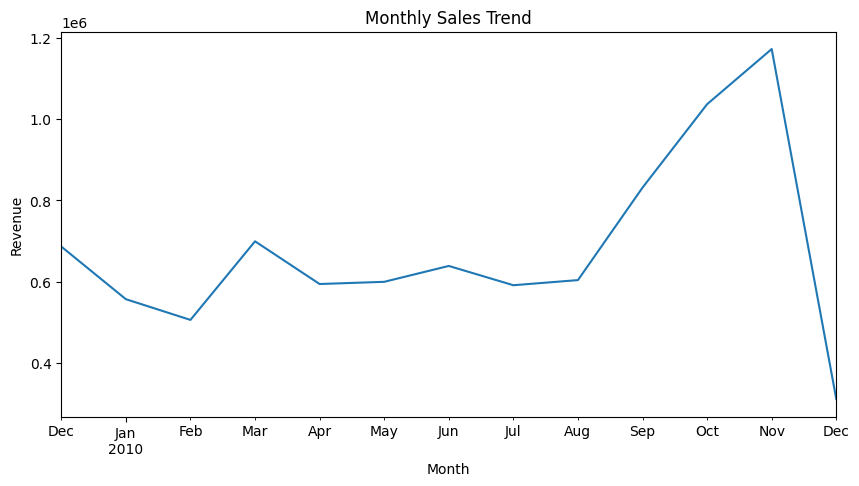

In [25]:
#seasonal trends
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [26]:
#7. Who are the top 10 customers by total spending?

top_customers = df.groupby("Customer ID")["Revenue"].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

top_customers

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196566.74
14911.0    152147.57
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

In [27]:
#8. What is the average order value?

order_value = df.groupby("Invoice")["Revenue"].sum()

order_value.mean()

np.float64(459.6889228126789)

In [28]:
#Orders by Hour (Shopping Behavior). Extract hour from InvoiceDate.
df["Hour"] = df["InvoiceDate"].dt.hour

In [29]:
#9. What time of day do customers place the most orders?

orders_by_hour = df.groupby("Hour")["Invoice"].count()

orders_by_hour

Hour
7       684
8      6645
9     19617
10    36070
11    51035
12    72433
13    67548
14    56228
15    43895
16    28918
17    13936
18     4517
19     4938
20     1200
Name: Invoice, dtype: int64

<Axes: xlabel='Hour'>

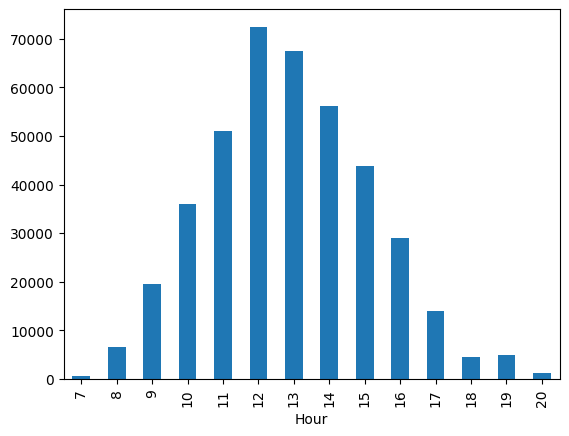

In [30]:
orders_by_hour.plot(kind="bar")

<Axes: xlabel='Country'>

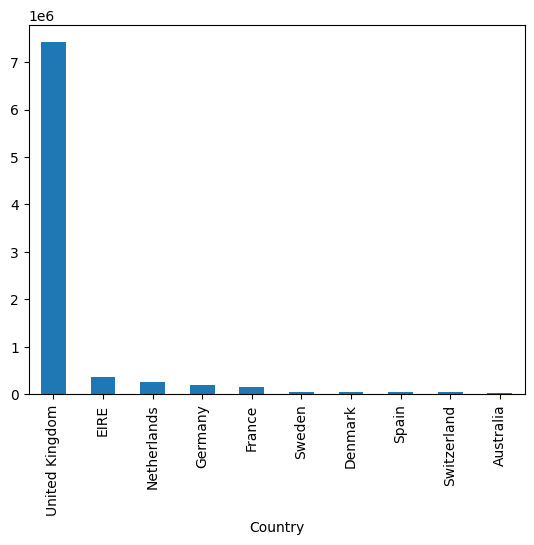

In [31]:
#Top Countries Visualization
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar")

In [40]:
df.to_csv(r"C:\Users\tejur\Downloads\cleaned1_ecommerce_data.csv", index=False)

In [ ]:
#RFM analysis [Recency Frequency Monetary]

In [ ]:
#Creating a Snapshot Date. need a reference date to calculate recency.
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
#This represents the day after the last transaction.

In [ ]:
#Create the RFM Table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

In [ ]:
#renaming columns
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [35]:
#Checking Customer Distribution for average spending, average purchase frequency, how recent customers are
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


In [36]:
#Create Customer Segments
rfm["CustomerSegment"] = "Low Value"

rfm.loc[(rfm["Frequency"] > 10) & (rfm["Monetary"] > 1000), "CustomerSegment"] = "High Value"

rfm.loc[(rfm["Frequency"] > 5) & (rfm["Monetary"] > 500), "CustomerSegment"] = "Medium Value"

In [37]:
#Count Customers in Each Segment
rfm["CustomerSegment"].value_counts()

CustomerSegment
Low Value       3380
Medium Value     932
Name: count, dtype: int64

<Axes: xlabel='CustomerSegment'>

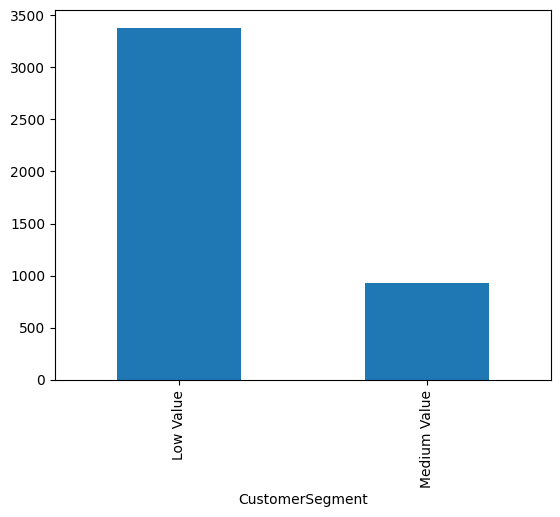

In [38]:
#Visualize Customer Segments
rfm["CustomerSegment"].value_counts().plot(kind="bar")

In [ ]:
#Most customers fall into the low-value category,while a small percentage generate the majority of revenue.
#High-value customers should be targeted with loyalty programs and personalized marketing campaigns.

In [ ]:
# ============================================================
# FINAL BUSINESS INSIGHTS + RFM INSIGHTS
# ============================================================

# 1. Revenue Performance
# The total revenue generated from the dataset is approximately $8.83 million,
# indicating strong sales performance across the recorded transactions.

# 2. Product Performance
# The most frequently purchased product is "WHITE HANGING HEART T-LIGHT HOLDER"
# with over 56,000 units sold, suggesting strong demand for home décor products.

# 3. Geographic Sales Distribution
# The United Kingdom generates the majority of the revenue (over $7.4 million),
# indicating that the business is highly concentrated in the UK market.

# 4. Seasonal Sales Trends
# Sales show noticeable peaks during December, suggesting strong holiday
# season demand and increased customer purchasing activity during this period.

# 5. Customer Value Insights
# Customer segmentation analysis shows that a small group of high-value
# customers contributes a significant portion of the total revenue,
# while most customers fall into lower-value segments.


# Customer Segmentation Insights (RFM Analysis)
#1. Recency Insight
# Customers who purchased recently are more likely to return and make additional purchases. 
# Some customers have not made purchases for a long time, which may indicate customer inactivity or potential churn.

#2. Frequency Insight
# A group of customers places orders frequently, demonstrating strong engagement with the business.
# These customers represent the company’s loyal and repeat buyers.

#3. Monetary Insight
# High-value customers contribute a significant share of total revenue. 
# These customers tend to purchase more frequently and spend more per transaction compared to the average customer.

#4. Customer Segment Distribution
# Based on RFM analysis, customers can be grouped into three main segments:
        # a. High-value customers – purchase frequently and generate the highest revenue.
        # b. Medium-value customers – purchase occasionally and contribute moderate revenue.
        # c. Low-value customers – purchase rarely and contribute lower transaction values.

# Business Recommendations
# Based on the analysis, the following strategies could help improve business performance:
# Focus marketing campaigns on top-performing products that generate the highest demand.
# Expand sales strategies into international markets to reduce reliance on the UK market.
# Launch seasonal promotions before the holiday period to maximize revenue during peak months.
# Develop loyalty programs and targeted offers to retain high-value customers.
# Implement re-engagement campaigns to encourage inactive customers to return and make purchases.